Best Parameters:
{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross Validation Accuracy:
0.9733333333333334

Cross Validation Scores:
[0.96666667 0.96666667 0.93333333 1.         1.        ]

Average Accuracy:
0.9733333333333334

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.98      0.94      0.96        50
   virginica       0.94      0.98      0.96        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



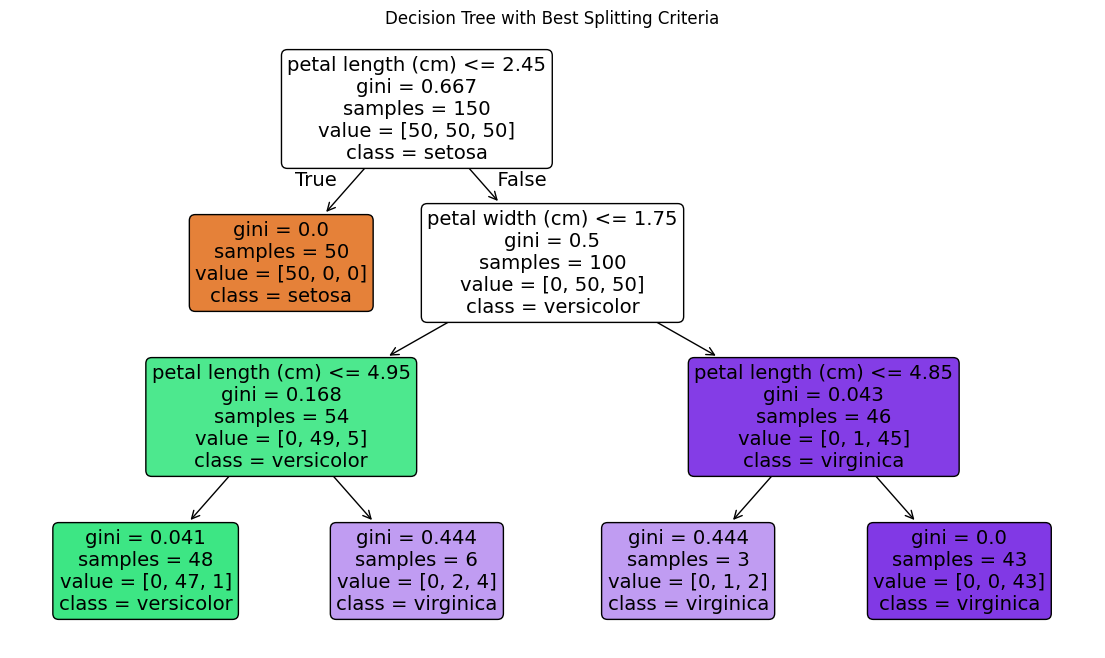

In [ ]:
# Decision Tree with Best Splitting Criteria and Cross Validation

import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Create Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Hyperparameter tuning for best splitting criteria
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3]
}

# Grid Search with 5-fold Cross Validation
grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X, y)

# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_search.best_score_)

# Best model
best_model = grid_search.best_estimator_

# Cross-validation scores of best model
cv_scores = cross_val_score(best_model, X, y, cv=5)

print("\nCross Validation Scores:")
print(cv_scores)

print("\nAverage Accuracy:")
print(cv_scores.mean())

# Train final model
best_model.fit(X, y)

# Predictions
y_pred = best_model.predict(X)

print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=iris.target_names))

# Visualize Decision Tree
plt.figure(figsize=(14, 8))
plot_tree(
    best_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)
plt.title("Decision Tree with Best Splitting Criteria")
plt.show()